## Dreamleague S21

In [2]:
%load_ext autoreload
%autoreload 2
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import os
from sqlalchemy.engine import create_engine, URL

from src.fetch_data.opendota_api import get_opendota_df
from src.process_data.preprocessing import preprocess_df
from src.process_data.team_features import create_team_level_features
from src.process_data.player_hero_features import create_player_hero_features
from src.process_data.heroes_features import create_hero_level_features


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# league_id number for dreamleague season 21
league_id = 15739

# constants
label_col = 'radiant_win'
time_col = 'start_time'
uuid_col = 'match_id'


In [4]:
url_object = URL.create(
    "postgresql+psycopg2",
    username='liuhaochen',
    host='localhost',
    port='5432',
    database='dota2'
)

engine = create_engine(url_object)

In [5]:
df = pd.read_sql(
    "SELECT * FROM pro_matches",
    con=engine
)

df = preprocess_df(df)

In [ ]:
df_dl = await get_opendota_df(f'leagues/{league_id}/matches')

,match_id,radiant_win,start_time,duration,leagueid,radiant_score,dire_score,radiant_team_id,radiant_team_name,dire_team_id,dire_team_name,series_id,series_type
0,7350448037,False,1695571081,2346,15739,17,25,39,None,7119388,None,809911,2
1,7350256732,True,1695565080,4104,15739,28,33,7119388,None,39,None,809911,2
2,7350011127,True,1695557886,2838,15739,34,18,39,None,8255888,None,809840,1
3,7349896441,True,1695553743,2304,15739,24,14,8255888,None,39,None,809840,1
4,7349788555,True,1695549358,2648,15739,35,9,39,None,8255888,None,809840,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,7342275176,False,1695127193,2337,15739,18,35,8255756,None,7119388,None,808465,1
82,7348581553,False,1695484080,2496,15739,24,45,39,None,7119388,None,809551,1
83,7343776797,False,1695217508,2563,15739,20,37,8255888,None,8255756,None,808703,1
84,7350558475,False,1695575340,2048,15739,17,39,39,None,7119388,None,809911,2


In [11]:
dl_match_ids = df_dl['match_id']
dl_match_ids

0     7350448037
1     7350256732
2     7350011127
3     7349896441
4     7349788555
         ...    
81    7342275176
82    7348581553
83    7343776797
84    7350558475
85    7343491898
Name: match_id, Length: 86, dtype: int64

In [12]:
dreamleague_dl = df[df['match_id'].isin(dl_match_ids)]
dreamleague_dl

,0_hero_id,1_hero_id,2_hero_id,3_hero_id,4_hero_id,128_hero_id,129_hero_id,130_hero_id,131_hero_id,132_hero_id,...,128_account_id,129_account_id,130_account_id,131_account_id,132_account_id,radiant_name,dire_name,radiant_win,start_time,match_id
32022,73.0,17.0,60.0,58.0,90.0,41.0,79.0,107.0,101.0,135.0,...,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-24 17:09:00,7350558475
32026,72.0,7.0,96.0,37.0,123.0,109.0,58.0,23.0,79.0,29.0,...,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-24 15:58:01,7350448037
32033,12.0,68.0,107.0,110.0,96.0,46.0,74.0,38.0,58.0,79.0,...,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,Team Spirit,Shopify Rebellion,True,2023-09-24 14:18:00,7350256732
32043,41.0,120.0,60.0,37.0,20.0,44.0,17.0,2.0,90.0,74.0,...,124801257.0,480412663.0,331855530.0,317880638.0,431770905.0,Shopify Rebellion,BetBoom Team,True,2023-09-24 12:18:06,7350011127
32050,8.0,46.0,2.0,3.0,110.0,138.0,120.0,29.0,53.0,20.0,...,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,BetBoom Team,Shopify Rebellion,True,2023-09-24 11:09:03,7349896441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32547,14.0,46.0,135.0,3.0,100.0,89.0,120.0,75.0,16.0,138.0,...,171262902.0,96803083.0,127565532.0,183719386.0,196878136.0,Shopify Rebellion,Entity,False,2023-09-18 11:18:55,7340745014
32548,37.0,93.0,101.0,38.0,114.0,7.0,137.0,20.0,18.0,90.0,...,100471531.0,301750126.0,101259972.0,375507918.0,193815691.0,Tundra Esports,Talon,True,2023-09-18 11:13:04,7340747836
32554,37.0,7.0,55.0,69.0,73.0,20.0,135.0,107.0,119.0,44.0,...,54580962.0,73562326.0,201358612.0,77490514.0,152962063.0,9Pandas,Team Liquid,True,2023-09-18 10:13:34,7340677613
32555,89.0,17.0,20.0,44.0,100.0,26.0,12.0,79.0,69.0,107.0,...,10366616.0,100058342.0,94786276.0,86698277.0,94054712.0,Talon,Tundra Esports,False,2023-09-18 09:58:40,7340671914


In [13]:
num_live_df = len(dreamleague_dl)
num_live_df 

86

In [14]:
cut_off_date = min(dreamleague_dl['start_time'])
cut_off_date

Timestamp('2023-09-18 09:57:33')

In [15]:
df_historical = df[df['start_time'] < cut_off_date]

In [16]:
combined_df = pd.concat([dreamleague_dl, df_historical])
combined_df

,0_hero_id,1_hero_id,2_hero_id,3_hero_id,4_hero_id,128_hero_id,129_hero_id,130_hero_id,131_hero_id,132_hero_id,...,128_account_id,129_account_id,130_account_id,131_account_id,132_account_id,radiant_name,dire_name,radiant_win,start_time,match_id
32022,73.0,17.0,60.0,58.0,90.0,41.0,79.0,107.0,101.0,135.0,...,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-24 17:09:00,7350558475
32026,72.0,7.0,96.0,37.0,123.0,109.0,58.0,23.0,79.0,29.0,...,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-24 15:58:01,7350448037
32033,12.0,68.0,107.0,110.0,96.0,46.0,74.0,38.0,58.0,79.0,...,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,Team Spirit,Shopify Rebellion,True,2023-09-24 14:18:00,7350256732
32043,41.0,120.0,60.0,37.0,20.0,44.0,17.0,2.0,90.0,74.0,...,124801257.0,480412663.0,331855530.0,317880638.0,431770905.0,Shopify Rebellion,BetBoom Team,True,2023-09-24 12:18:06,7350011127
32050,8.0,46.0,2.0,3.0,110.0,138.0,120.0,29.0,53.0,20.0,...,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,BetBoom Team,Shopify Rebellion,True,2023-09-24 11:09:03,7349896441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88078,58.0,98.0,19.0,42.0,111.0,41.0,68.0,96.0,128.0,46.0,...,874542740.0,67893845.0,93159453.0,79818006.0,172739956.0,Wind and Rain,felt,False,2021-05-18 00:02:06,5999283181
88079,126.0,78.0,109.0,128.0,102.0,86.0,96.0,106.0,94.0,68.0,...,126469785.0,118207269.0,230580807.0,318588173.0,76600360.0,felt,Wind and Rain,False,2021-05-17 23:02:25,5999249937
88080,96.0,123.0,15.0,121.0,72.0,23.0,2.0,94.0,128.0,30.0,...,874542740.0,93159453.0,172739956.0,79818006.0,67893845.0,Wind and Rain,felt,False,2021-05-17 22:02:01,5999214195
88081,68.0,58.0,97.0,106.0,19.0,111.0,17.0,61.0,88.0,6.0,...,97366926.0,97072681.0,71266407.0,184131721.0,107579895.0,Infinity,Crewmates,True,2021-05-17 21:40:35,5999201501


In [17]:
team_level_features = create_team_level_features(combined_df, num_live_df)
team_level_features

,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_win,start_time,match_id
32022,0.600000,0.5,0.7,False,2023-09-24 17:09:00,7350558475
32026,0.600000,0.5,0.7,False,2023-09-24 15:58:01,7350448037
32033,0.400000,0.7,0.5,True,2023-09-24 14:18:00,7350256732
32043,0.555556,0.5,0.3,True,2023-09-24 12:18:06,7350011127
32050,0.375000,0.3,0.5,True,2023-09-24 11:09:03,7349896441
...,...,...,...,...,...,...
32547,0.400000,0.5,0.6,False,2023-09-18 11:18:55,7340745014
32548,0.800000,0.7,0.8,True,2023-09-18 11:13:04,7340747836
32554,0.375000,0.7,0.3,True,2023-09-18 10:13:34,7340677613
32555,0.200000,0.8,0.7,False,2023-09-18 09:58:40,7340671914


In [18]:
heroes_features = create_hero_level_features(combined_df, num_live_df)
heroes_features

/home/ubuntu/projects/dota2pred/backend/src/process_data/heroes_features.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[DRAFT_COLS] = df[DRAFT_COLS].applymap(hero_dict.get)


,match_id,radiant_win_x,Abaddon,Alchemist,Ancient Apparition,Anti-Mage,Arc Warden,Axe,Bane,Batrider,...,Void Spirit,Warlock,Weaver,Windranger,Winter Wyvern,Witch Doctor,Wraith King,Zeus,start_time,radiant_win_y
55611,7350558475,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2023-09-24 17:09:00,False
55610,7350448037,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,2023-09-24 15:58:01,False
55609,7350256732,10,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2023-09-24 14:18:00,True
55608,7350011127,10,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,2023-09-24 12:18:06,True
55607,7349896441,10,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,2023-09-24 11:09:03,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55530,7340747836,10,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,2023-09-18 11:13:04,True
55529,7340745014,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,2023-09-18 11:18:55,False
55528,7340677613,10,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,2023-09-18 10:13:34,True
55527,7340676064,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,2023-09-18 09:57:33,False


In [19]:
player_hero_features = create_player_hero_features(combined_df, num_live_df)
player_hero_features

/home/ubuntu/projects/dota2pred/backend/src/process_data/player_hero_features.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['win_rate'] = df_subset.apply(lambda row: last_10_matches_winrate(df_combined, row[TIME_COL], row['account_id'], row['hero_id']), axis=1)
/home/ubuntu/projects/dota2pred/backend/src/process_data/player_hero_features.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['player_hero_win_rate_col'] = df_subset['player_num'].astype(str) + '_account_ ' + df_subset

player_hero_win_rate_col,match_id,0_account_ 0_hero_win_rate,128_account_ 128_hero_win_rate,129_account_ 129_hero_win_rate,130_account_ 130_hero_win_rate,131_account_ 131_hero_win_rate,132_account_ 132_hero_win_rate,1_account_ 1_hero_win_rate,2_account_ 2_hero_win_rate,3_account_ 3_hero_win_rate,4_account_ 4_hero_win_rate
85,7350558475,0.400000,0.900000,0.700000,0.750000,0.700000,0.666667,0.60,0.600000,0.600000,0.444444
84,7350448037,1.000000,0.800000,0.700000,0.700000,0.600000,0.600000,0.50,0.500000,0.833333,0.500000
83,7350256732,0.800000,0.500000,0.500000,0.400000,0.700000,0.625000,0.70,0.666667,0.700000,0.500000
82,7350011127,0.444444,0.000000,0.700000,0.600000,0.900000,0.600000,0.60,0.500000,0.800000,0.666667
81,7349896441,0.500000,0.800000,0.600000,0.400000,0.500000,0.750000,0.80,0.600000,0.600000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...
4,7340747836,0.333333,0.500000,0.000000,0.250000,0.800000,0.625000,0.80,0.333333,0.600000,0.600000
3,7340745014,0.666667,0.400000,0.500000,0.400000,0.500000,0.500000,0.75,0.375000,0.800000,0.600000
2,7340677613,0.000000,0.400000,0.428571,0.500000,0.571429,0.000000,0.75,0.600000,0.700000,0.700000
1,7340676064,0.500000,0.833333,0.714286,0.285714,0.600000,0.500000,0.60,0.833333,0.500000,0.666667


In [20]:
df_final = pd.merge(pd.merge(team_level_features,heroes_features,how='inner', on=[time_col,label_col,uuid_col]), player_hero_features, how='inner', on=uuid_col)
df_final

KeyError: 'radiant_win'

In [21]:
from src.fetch_data import process_label, process_features

X = process_features(df_final)
y = process_label(df_final)

print(X.shape)
print(y.shape)

(86, 137)
(86,)


In [23]:
from joblib import load
from src.config import ROOT_DIR
clf = load(f'{ROOT_DIR}/models/random_forest_model.joblib')

In [27]:
y_pred = clf.predict(X)

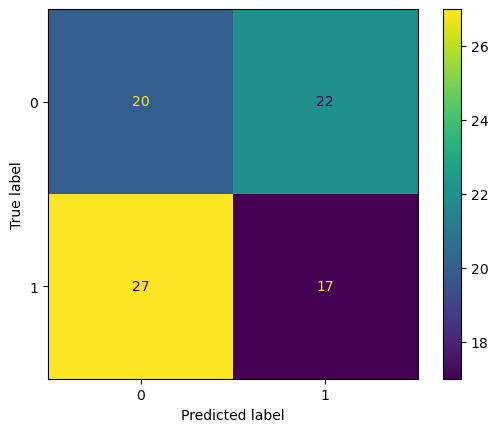

In [29]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [30]:
from sklearn.metrics import accuracy_score

accuracy_score(y, y_pred) 

# Such high accuracy score might be an indication of ??

0.43023255813953487